In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from time import time
import scipy.spatial as ssp
import scipy.sparse.linalg as sla
import sklearn as sk
import plotly.express as px
import heapq
import seaborn as sns

In [2]:
!pip install --upgrade numpy
!pip install --upgrade --force-reinstall gensim
import gensim.downloader as api

  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (

#NLP (to provide an initial impression of the categories)

In [3]:
corpus = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [4]:
cats = ["church","resort","beach","park","theater","museum","mall","zoo","restaurant","pub",
        "services", "pizzeria", "hotel", "refreshments","gallery","nightclub",
        "pool", "gym","bakery","spa", "cafe", "panorama", "monument","garden"] # note some had to be renamed to fit in the corpus

dist_mat = np.zeros((len(cats),len(cats)))
for i in range(len(cats)):
  dist_mat[i,:] = corpus.distances(cats[i],cats)
dist_mat

array([[ 0.00000000e+00,  8.74361515e-01,  8.07601869e-01,
         7.39569187e-01,  7.53727376e-01,  6.61844790e-01,
         7.75634229e-01,  7.56540716e-01,  7.68463373e-01,
         7.36874044e-01,  8.64283681e-01,  7.55096674e-01,
         8.22358608e-01,  7.99625993e-01,  8.09056818e-01,
         7.96906829e-01,  9.23402190e-01,  6.95109785e-01,
         7.24293530e-01,  8.43465567e-01,  7.60724068e-01,
         9.06806469e-01,  7.14003682e-01,  7.27393746e-01],
       [ 8.74361515e-01,  0.00000000e+00,  5.72504044e-01,
         7.16127694e-01,  8.45109522e-01,  8.74957383e-01,
         7.24782228e-01,  7.89319098e-01,  6.79484963e-01,
         7.68037558e-01,  9.14413452e-01,  8.46962631e-01,
         4.20168102e-01,  9.86961126e-01,  9.53201652e-01,
         7.04273880e-01,  8.20694447e-01,  8.41326892e-01,
         8.67289901e-01,  4.70316291e-01,  7.80341983e-01,
         8.35978091e-01,  8.54617476e-01,  8.71674836e-01],
       [ 8.07601869e-01,  5.72504044e-01, -1.19209290e

In [5]:
vecmat = pd.DataFrame(corpus[cats].T, columns=cats)

In [6]:
vecmat.to_csv("category_vecs.csv")

<Axes: >

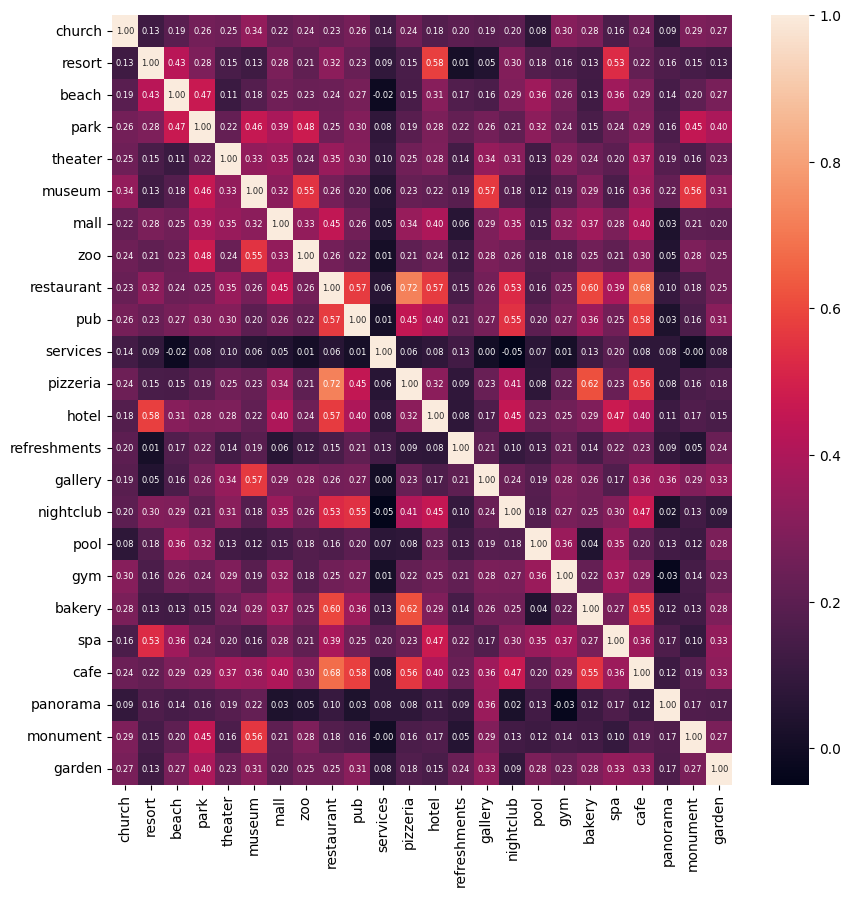

In [7]:
fig = plt.figure(figsize=(10,10))
sns.heatmap(1-dist_mat,annot=True,annot_kws={"size":6},
            figure=fig, xticklabels=cats, yticklabels=cats, fmt=".2f")

In [8]:
n_clust = 8 # play around with this
clust = sk.cluster.AgglomerativeClustering(n_clusters=n_clust, metric="precomputed", linkage="complete")
clust.fit(dist_mat)
for i in range(n_clust):
  print([cats[j] for j in range(len(cats)) if clust.labels_[j] == i])
  #print(cats[np.argwhere(clust.labels_ == i)])

['theater', 'mall', 'restaurant', 'pub', 'pizzeria', 'nightclub', 'bakery', 'cafe']
['park', 'museum', 'zoo', 'gallery', 'monument', 'garden']
['resort', 'hotel', 'spa']
['church', 'gym']
['panorama']
['services']
['refreshments']
['beach', 'pool']


#Data, MDS and Isomap

In [9]:
data = 'https://raw.githubusercontent.com/whosphong/DATA-STRUCTURES-AND-PLATFORMS---UAmath509/refs/heads/main/google_review_ratings.csv'
df = pd.read_csv(data)
df.drop(columns=['User', 'Unnamed: 25'], inplace=True)
df = df.rename(columns = {"Category 1": "C1", "Category 2": "C2", "Category 3": "C3", "Category 4": "C4", "Category 5": "C5",
                          "Category 6": "C6", "Category 7": "C7", "Category 8": "C8", "Category 9": "C9", "Category 10": "C10",
                          "Category 11": "C11", "Category 12": "C12", "Category 13": "C13", "Category 14": "C14", "Category 15": "C15", "Category 16": "C16",
                          "Category 17": "C17", "Category 18": "C18", "Category 19": "C19", "Category 20": "C20", "Category 21": "C21", "Category 22": "C22",
                          "Category 23": "C23", "Category 24": "C24"}).copy()
df = df[df.duplicated() == False]

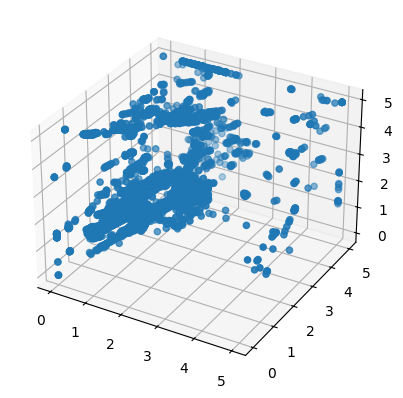

In [10]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(df['C1'],df['C2'],df['C3'])
plt.show()

In [47]:
n = 5451
df_arr = np.asarray(df)[:n,:]
dots = df_arr @ df_arr.T
normsqs = np.diag(dots)
n_clust = 9
n_dims = 3

In [48]:
def center(arr, axis):
  return arr - np.mean(arr, axis=axis, keepdims=True)

def MDS(D):     # input squared distance matrix, return matrix of MDS points
  B = -center(center(D, axis=0), axis=1)/2
  w, v = sla.eigsh(B, k=n_dims)
  return v @ np.diag(w)**0.5

In [49]:
# euclidean distance
X = MDS(normsqs[:,None] + normsqs[None,:] - 2*dots)
kmeans_2 = sk.cluster.KMeans(n_clusters=n_clust, random_state=0).fit(X)
if n_dims == 3:
  fig = px.scatter_3d(x=X[:,0],y=X[:,1],z=X[:,2],color=kmeans_2.labels_)
  fig.show()


In [50]:
sk.metrics.silhouette_score(X, kmeans_2.labels_)

0.3159382830375275

In [51]:
# infinity norm
X = MDS(ssp.distance_matrix(df_arr, df_arr, p=np.inf))
kmeans_inf = sk.cluster.KMeans(n_clusters=n_clust, random_state=0).fit(X)
if n_dims == 3:
  fig = px.scatter_3d(x=X[:,0],y=X[:,1],z=X[:,2],color=kmeans_inf.labels_)
  fig.show()


In [52]:
sk.metrics.silhouette_score(X, kmeans_inf.labels_)

0.3685569837676411

In [53]:
# attempt at doing isomap (unfinished)
k = 5
dist = ssp.distance_matrix(df_arr, df_arr)
nearinds = np.argsort(dist)
neighbors = nearinds[:,1:k+1]
neighdists = np.zeros_like(neighbors,dtype=float)
for i,j in enumerate(neighbors):
  neighdists[i,:] = dist[i,j]
print(neighdists)

[[0.28124722 0.29017236 0.29068884 0.50129831 1.36128616]
 [0.02236068 0.02645751 0.29017236 0.57922362 1.33667498]
 [0.02       0.02236068 0.29068884 0.57879185 1.33701159]
 ...
 [1.50794562 3.49114594 4.06918911 4.2121491  4.21679973]
 [1.16133544 1.28296532 3.91573748 4.16140601 4.24028301]
 [1.50794562 3.79828909 4.09388568 4.2571117  4.31113674]]


In [54]:
for i in [4,1,2,3,9,10,11]:
  print(neighbors[i,:])

[2 1 0 3 9]
[2 4 0 3 9]
[4 1 0 3 9]
[0 4 2 1 9]
[10 11  3  1  2]
[ 9 11  3  1  2]
[10  9  3  1  4]


In [55]:
def dijkstra(neighbors, dists, start):
  q = []
  d = {start: 0}
  heapq.heappush(q, (0, start))
  while q:
    _, u = heapq.heappop(q)
    for j in range(k):
      v = neighbors[u,j]
      alt = d[u] + dists[u,j]
      if v not in d or alt < d[v]:
        d[v] = alt
        heapq.heappush(q, (alt, v))
  return d

In [56]:
'''a = np.zeros((n,n))
start = time()
for i in range(5):
  d = dijkstra(neighbors, neighdists, i)
  a[i,:] = np.array(sorted(d.items()))[:,1]'''

'a = np.zeros((n,n))\nstart = time()\nfor i in range(5):\n  d = dijkstra(neighbors, neighdists, i)\n  a[i,:] = np.array(sorted(d.items()))[:,1]'

In [57]:
dijkstra(neighbors, neighdists, 0)

{0: 0,
 4: 0.28124722220850445,
 1: 0.2901723625709382,
 2: 0.2906888370749727,
 3: 0.5012983143797713,
 9: 1.3612861565446113,
 10: 1.3912861565446113,
 11: 1.7739603621838782}

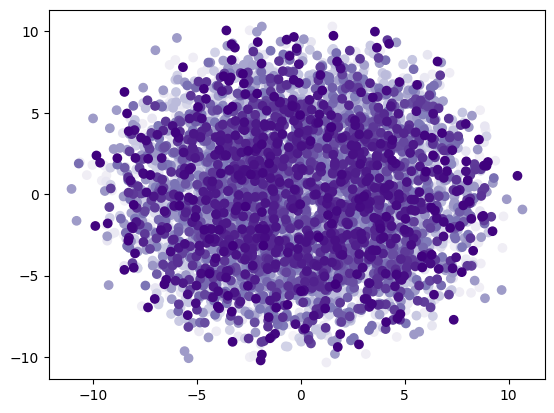

In [58]:
#''' sklearn method, is a lot slower than manual MDS
embedding = sk.manifold.MDS(n_init = 1, max_iter = 5)
X = embedding.fit_transform(df_arr)

fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(X[:,0],X[:,1], c=np.arange(n), cmap='Purples')
plt.show()


In [59]:
embedding = sk.manifold.Isomap(n_neighbors=10, n_components=3)
X = embedding.fit_transform(df_arr)

kmeans_iso = sk.cluster.KMeans(n_clusters=n_clust, random_state=0).fit(X)

fig = px.scatter_3d(x=X[:,0],y=X[:,1],z=X[:,2],color=kmeans_iso.labels_)
fig.show()

In [65]:
fig = px.scatter_3d(x=X[:,0],y=X[:,1],z=X[:,2],color=kmeans_2.labels_)
fig.show()

In [68]:
pd.DataFrame(np.array([kmeans_2.labels_, kmeans_inf.labels_, kmeans_iso.labels_]).T,columns=["MDS2", "MDSInf", "Isomap"]).to_csv("mds_labels.csv")